In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import pickle
import decoupler as dc
import matplotlib.pyplot as plt

In [4]:
sc.set_figure_params(facecolor=None, frameon=False, vector_friendly=True, transparent=True)
sc.settings._vector_friendly = False
sc.settings.verbosity = 2

In [5]:
# set working directory
project_dir = os.path.expanduser("~/BreastCancerG0arrest/")
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# figure directory
figure_dir = working_dir + "figures/"
# data directory
data_dir = working_dir + "data/"

In [6]:
adata_full = sc.read_h5ad(data_dir + "adata_full_harmony_integration.h5ad")

In [7]:
adata = adata_full[adata_full.obs["malignancy"] == "malignant"].copy()

adata.X = adata.layers["counts"].copy()
sc.pp.filter_genes(adata, min_cells=20)
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

filtered out 590 genes that are detected in less than 20 cells
normalizing counts per cell
    finished (0:00:01)


In [14]:
hallmark = dc.op.hallmark(organism="human")
dc.mt.ulm(data=adata, net=hallmark)
score = dc.pp.get_obsm(adata=adata, key="score_ulm")
df = dc.tl.rankby_group(adata=score, groupby="cycling_state_oren", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]

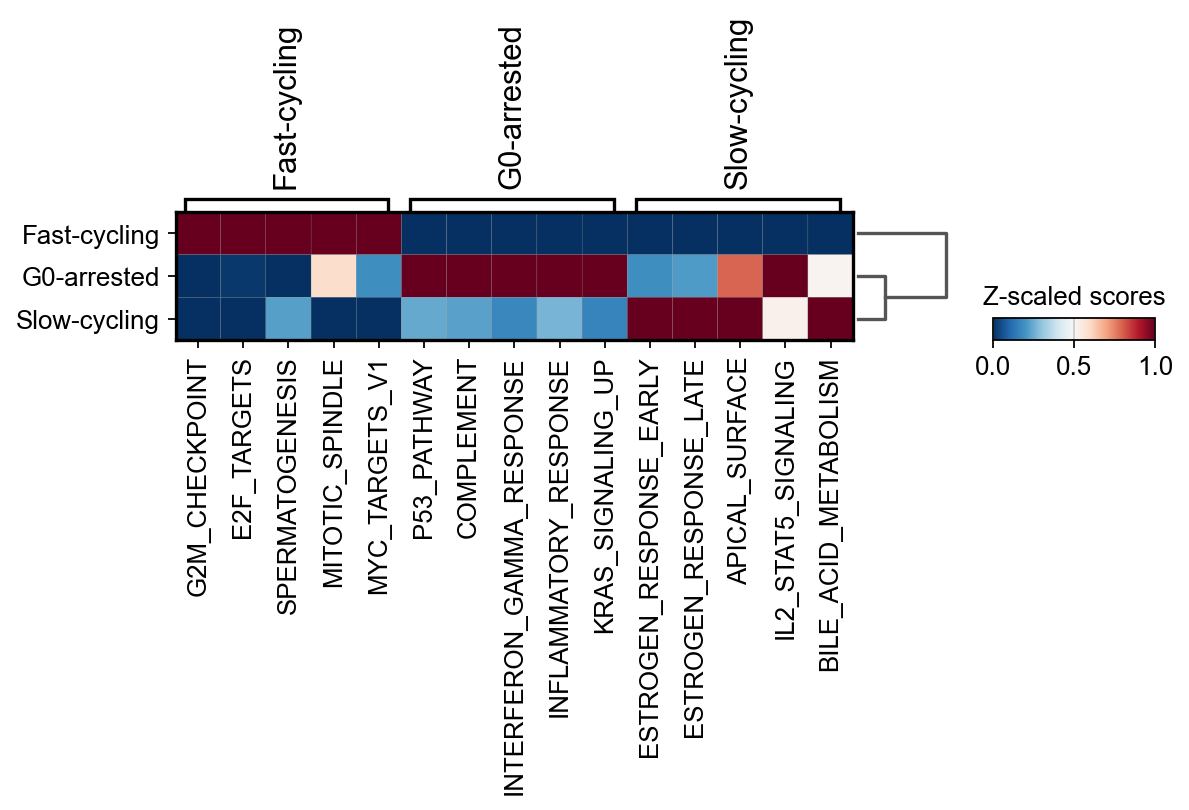

In [15]:
n_markers = 5
source_markers = (
    df.groupby("group")
    .head(n_markers)
    .drop_duplicates("name")
    .groupby("group")["name"]
    .apply(lambda x: list(x))
    .to_dict()
)
source_markers

sc.pl.matrixplot(
    adata=score,
    var_names=source_markers,
    groupby="cycling_state_oren",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
    save="hallmarks_cycling_states.pdf",
)

In [16]:
adata

AnnData object with n_obs × n_vars = 85749 × 23309
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'type', 'patient', 'annotation', 'percent.mt', 'Phase', 'CC.Difference', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'integrated_snn_res.2', 'celltype', 'malignancy', 'cellclass', 'quiescence_score', 'cycling_state', 'QuiescenceType', 'disease', 'ident', 'oren_quiescence', 'cycling_state_oren'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_name', 'celltype_colors', 'cycling_state_colors', 'cycling_state_oren_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'type_colors', 'umap', 'dendrogram_cycling_state_oren'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'score_aucell', 'score_ulm', 'padj_ulm'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

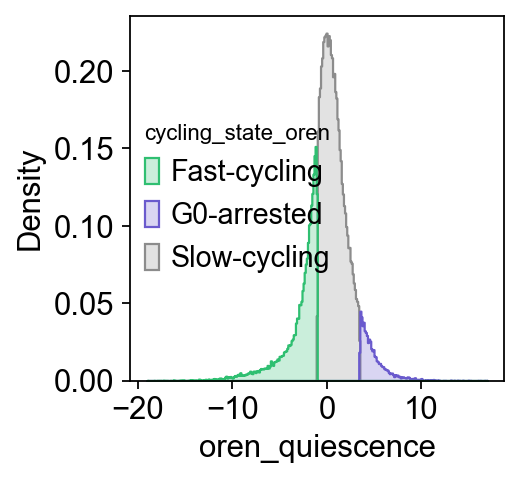

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

df = adata.obs[["oren_quiescence", "cycling_state_oren"]].copy()

adata.uns["cycling_state_oren_colors"] = [
    "#2FBF71",
    "#6A5ACD",
    "#8C8C8C",
]

fig = plt.figure(figsize=(3, 3))
sns.histplot(
    df,
    x="oren_quiescence",
    hue="cycling_state_oren",
    element="step",
    stat="density",
    common_norm=True,
    palette=adata.uns["cycling_state_oren_colors"],
)
plt.grid(False)
plt.savefig(figure_dir + "cycling_state_oren_vs_oren_quiescence.pdf")
plt.show()

In [18]:
import seaborn as sns
from scipy.stats import mannwhitneyu
import itertools
import math


def gene_expression(
    adata,
    group_column: str,
    genes,
    layer: str = None,
    order=None,
    colours=None,
    figsize=(3, 3),
    xlabel=None,
    ylabel=None,
    title=None,
    log_y=False,
    save_path=None,
    return_stats=False,
):
    """
    Violin + box plots of gene expression grouped by a categorical column in adata.obs.
    Adds significance stars (only for p < 0.05) based on pairwise Mann–Whitney U tests.
    Supports multiple genes in subplots.

    Parameters
    ----------
    adata : AnnData
        Input AnnData object.
    group_column : str
        Column in adata.obs defining groups.
    genes : str or list
        Gene name or list of gene names.
    layer : str, optional
        Layer to extract expression from instead of adata.X.
    order : list, optional
        Order of groups on x-axis.
    colours : list, optional
        List of colours for groups, in same order as `order` or categorical order.
    figsize : tuple, default (3,3)
        Size of each subplot.
    xlabel, ylabel : str, optional
        Axis labels.
    title : str, optional
        Global figure title.
    log_y : bool, default False
        Log scale for y-axis.
    save_path : str, optional
        Path to save figure.
    return_stats : bool, default False
        If True, returns DataFrame of pairwise p-values.

    Returns
    -------
    DataFrame of pairwise stats if return_stats=True.
    """

    if isinstance(genes, str):
        genes = [genes]

    for g in genes:
        if g not in adata.var_names:
            raise ValueError(f"Gene '{g}' not found in adata.var_names")

    groups = adata.obs[group_column].dropna().unique()
    if order is None:
        order = sorted(groups)

    # custom colour list
    if colours is not None:
        if len(colours) < len(order):
            raise ValueError("Number of colours must match number of groups")
        palette = dict(zip(order, colours))
    else:
        palette = dict(zip(order, sns.color_palette("Set2", len(order))))

    n_genes = len(genes)
    ncols = min(3, n_genes)
    nrows = math.ceil(n_genes / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(figsize[0] * ncols, figsize[1] * nrows), squeeze=False
    )
    stats_all = []

    for idx, gene in enumerate(genes):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]

        X = adata[:, gene].layers[layer] if layer else adata[:, gene].X

        if hasattr(X, "toarray"):
            expr = X.toarray().ravel()
        else:
            expr = np.asarray(X).ravel()


        obs = adata.obs[[group_column]].copy()
        obs["expression"] = expr
        obs = obs.dropna(subset=["expression"])

        sns.violinplot(
            data=obs,
            x=group_column,
            y="expression",
            order=order,
            palette=palette,
            inner="box",
            ax=ax,
            cut=0,
        )

        ax.set_xlabel(xlabel or group_column, fontsize=10)
        ax.set_ylabel(ylabel or "Expression", fontsize=10)
        ax.set_title(gene, fontsize=11)
        if log_y:
            ax.set_yscale("log")
        sns.despine(ax=ax)

        pairs = list(itertools.combinations(order, 2))
        ymax = obs["expression"].max()
        y_offsets = np.linspace(0.05 * ymax, 0.2 * ymax, len(pairs))

        for i, (g1, g2) in enumerate(pairs):
            d1 = obs.loc[obs[group_column] == g1, "expression"]
            d2 = obs.loc[obs[group_column] == g2, "expression"]
            stat, p = mannwhitneyu(d1, d2, alternative="two-sided")
            stats_all.append(
                {"gene": gene, "group1": g1, "group2": g2, "U": stat, "pvalue": p}
            )

            # only annotate if significant
            if p < 0.05:
                if p < 0.001:
                    stars = "***"
                elif p < 0.01:
                    stars = "**"
                else:
                    stars = "*"

                x1, x2 = order.index(g1), order.index(g2)
                y = ymax + y_offsets[i]
                ax.plot(
                    [x1, x1, x2, x2],
                    [y - 0.02 * ymax, y, y, y - 0.02 * ymax],
                    lw=1,
                    c="black",
                )
                ax.text(
                    (x1 + x2) / 2,
                    y + 0.02 * ymax,
                    stars,
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

        ax.tick_params(axis="both", labelsize=9)
        ax.grid(False)

    # remove unused axes
    for j in range(idx + 1, nrows * ncols):
        fig.delaxes(axes.flatten()[j])

    if title:
        fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    if title:
        plt.subplots_adjust(top=0.9)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

    if return_stats:
        return pd.DataFrame(stats_all)


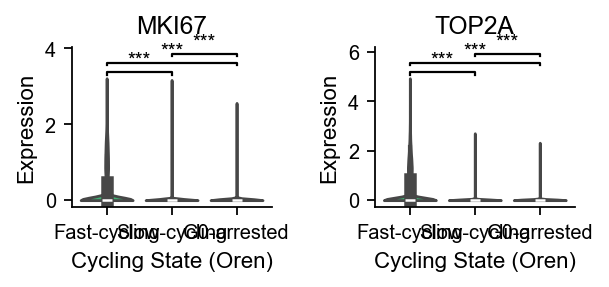

In [19]:
gene_expression(
    adata,
    group_column="cycling_state_oren",
    genes=[
        "MKI67",
        "TOP2A"
    ],
    order=["Fast-cycling", "Slow-cycling", "G0-arrested"],
    colours=adata.uns["cycling_state_oren_colors"],
    figsize=(2, 2),
    xlabel="Cycling State (Oren)",
    ylabel="Expression",
    log_y=False,
    save_path=figure_dir + "gene_expression_cycling_states.pdf",
)

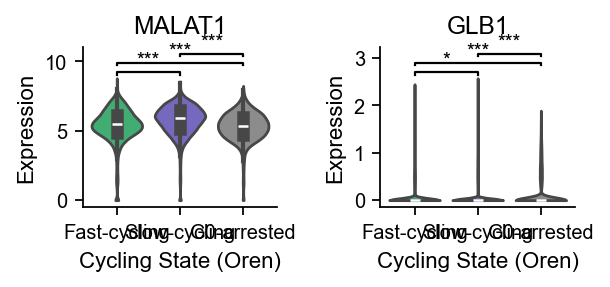

In [20]:
gene_expression(
    adata,
    group_column="cycling_state_oren",
    genes=["MALAT1", "GLB1"],
    order=["Fast-cycling", "Slow-cycling", "G0-arrested"],
    colours=adata.uns["cycling_state_oren_colors"],
    figsize=(2, 2),
    xlabel="Cycling State (Oren)",
    ylabel="Expression",
    log_y=False,
    save_path=figure_dir + "gene_expression_qc.pdf",
)


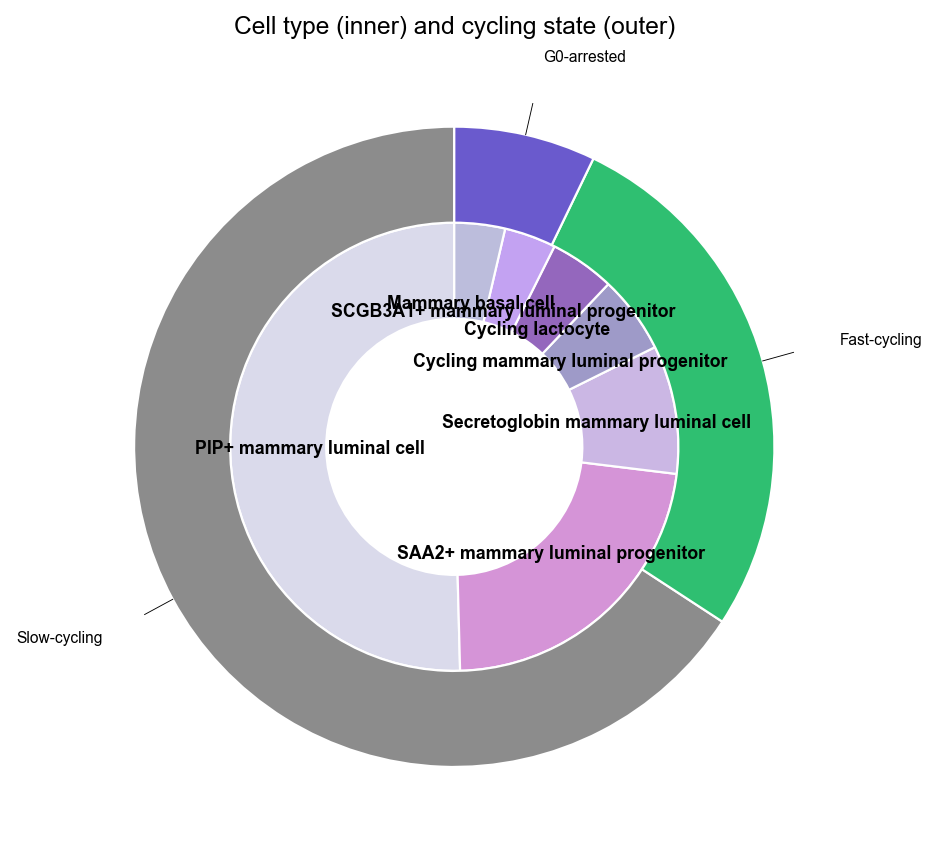

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

adata.obs["celltype"] = adata.obs["celltype"].cat.remove_unused_categories()

cycling_state_colors = adata.uns["cycling_state_oren_colors"]
type_colors = adata.uns["celltype_colors"]

df = adata.obs[["cycling_state_oren", "celltype"]].copy()

# Colour lookup tables (categorical order)
cycling_state_levels = adata.obs["cycling_state_oren"].cat.categories.tolist()
type_levels = adata.obs["celltype"].cat.categories.tolist()

cycling_state_color_map = dict(zip(cycling_state_levels, cycling_state_colors))
type_color_map = dict(zip(type_levels, type_colors))

# Proportions
prop_cycling_state = df["cycling_state_oren"].value_counts(normalize=True)
prop_celltype = df["celltype"].value_counts(normalize=True)


# Enforce ordering: move "normal" to the end
def move_normal_to_end(index):
    idx = [x for x in index if x != "normal"]
    if "normal" in index:
        idx.append("normal")
    return idx


# Swapped: celltype is now inner, cycling_state is now outer
inner_labels = move_normal_to_end(prop_celltype.index.tolist())
outer_labels = move_normal_to_end(prop_cycling_state.index.tolist())

inner_fracs = prop_celltype.loc[inner_labels].values
outer_fracs = prop_cycling_state.loc[outer_labels].values

inner_colors = [type_color_map[t] for t in inner_labels]
outer_colors = [cycling_state_color_map[m] for m in outer_labels]

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")

# Inner donut: celltype
wedges_inner, _ = ax.pie(
    inner_fracs,
    radius=0.7,
    startangle=90,
    colors=inner_colors,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Outer donut: cycling_state
wedges_outer, _ = ax.pie(
    outer_fracs,
    radius=1.0,
    startangle=90,
    colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Inner labels
for wedge, label in zip(wedges_inner, inner_labels):
    angle = (wedge.theta1 + wedge.theta2) / 2
    x = 0.45 * np.cos(np.deg2rad(angle))
    y = 0.45 * np.sin(np.deg2rad(angle))
    ax.text(x, y, label, ha="center", va="center", fontsize=8, weight="bold")

# Outer labels
for wedge, label in zip(wedges_outer, outer_labels):
    angle = (wedge.theta1 + wedge.theta2) / 2
    x = 1.25 * np.cos(np.deg2rad(angle))
    y = 1.25 * np.sin(np.deg2rad(angle))
    ha = "left" if x > 0 else "right"
    ax.text(x, y, label, ha=ha, va="center", fontsize=7)
    ax.plot(
        [np.cos(np.deg2rad(angle)), 1.1 * np.cos(np.deg2rad(angle))],
        [np.sin(np.deg2rad(angle)), 1.1 * np.sin(np.deg2rad(angle))],
        color="black",
        lw=0.4,
    )

ax.set_title("Cell type (inner) and cycling state (outer)", fontsize=11)

plt.tight_layout()
plt.savefig(
    f"{figure_dir}/nested_donut_cycling_state_celltype.pdf", bbox_inches="tight"
)
plt.show()


In [44]:
adata.uns["type_colors"] = [
    "#BBFFAB",
    "#41F6D9",
    "#FF95B9",
    "#FFD3AE",
    "#F782FF",
    "#FFEF9A"
]

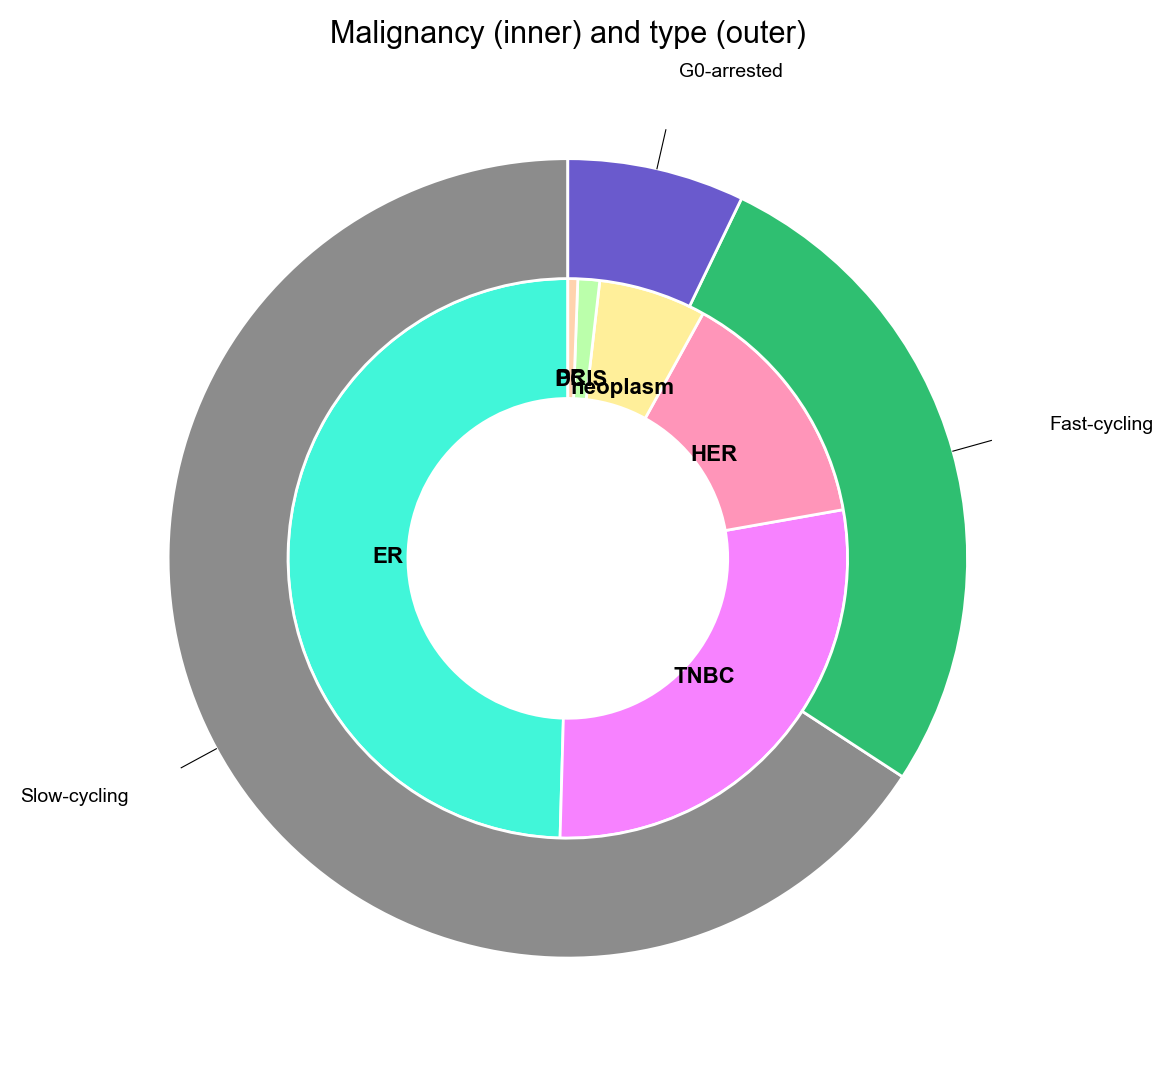

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

adata.obs["type"] = adata.obs["type"].cat.remove_unused_categories()

cycling_state_colors = adata.uns["cycling_state_oren_colors"]
type_colors = adata.uns["type_colors"]

df = adata.obs[["cycling_state_oren", "type"]].copy()

# Colour lookup tables (categorical order)
cycling_state_levels = adata.obs["cycling_state_oren"].cat.categories.tolist()
type_levels = adata.obs["type"].cat.categories.tolist()
cycling_state_color_map = dict(zip(cycling_state_levels, cycling_state_colors))
type_color_map = dict(zip(type_levels, type_colors))

# Proportions
prop_cycling_state = df["cycling_state_oren"].value_counts(normalize=True)
prop_type = df["type"].value_counts(normalize=True)


# Enforce ordering: move "normal" to the end
def move_normal_to_end(index):
    idx = [x for x in index if x != "normal"]
    if "normal" in index:
        idx.append("normal")
    return idx


inner_labels = move_normal_to_end(prop_type.index.tolist())
outer_labels = move_normal_to_end(prop_cycling_state.index.tolist())

inner_fracs = prop_type.loc[inner_labels].values
outer_fracs = prop_cycling_state.loc[outer_labels].values

inner_colors = [type_color_map[m] for m in inner_labels]
outer_colors = [cycling_state_color_map[t] for t in outer_labels]

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")

# Inner donut: malignancy
wedges_inner, _ = ax.pie(
    inner_fracs,
    radius=0.7,
    startangle=90,
    colors=inner_colors,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Outer donut: type
wedges_outer, _ = ax.pie(
    outer_fracs,
    radius=1.0,
    startangle=90,
    colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Inner labels
for wedge, label in zip(wedges_inner, inner_labels):
    angle = (wedge.theta1 + wedge.theta2) / 2
    x = 0.45 * np.cos(np.deg2rad(angle))
    y = 0.45 * np.sin(np.deg2rad(angle))
    ax.text(x, y, label, ha="center", va="center", fontsize=8, weight="bold")

# Outer labels
for wedge, label in zip(wedges_outer, outer_labels):
    angle = (wedge.theta1 + wedge.theta2) / 2
    x = 1.25 * np.cos(np.deg2rad(angle))
    y = 1.25 * np.sin(np.deg2rad(angle))
    ha = "left" if x > 0 else "right"
    ax.text(x, y, label, ha=ha, va="center", fontsize=7)
    ax.plot(
        [np.cos(np.deg2rad(angle)), 1.1 * np.cos(np.deg2rad(angle))],
        [np.sin(np.deg2rad(angle)), 1.1 * np.sin(np.deg2rad(angle))],
        color="black",
        lw=0.4,
    )

ax.set_title("Malignancy (inner) and type (outer)", fontsize=11)

plt.tight_layout()
plt.savefig(
    f"{figure_dir}/nested_donut_cycling_state_type.pdf", bbox_inches="tight"
)
plt.show()


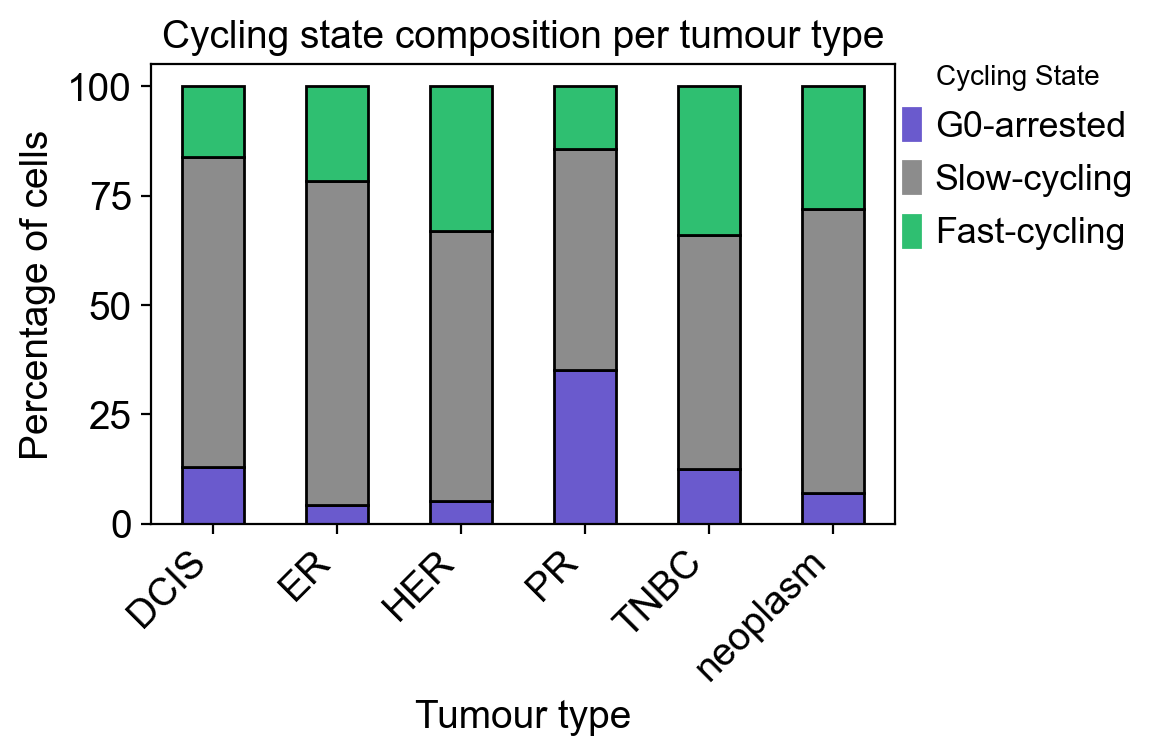

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Custom colours
group_colors = {
    "G0-arrested": "#6A5ACD",
    "Slow-cycling": "#8C8C8C",
    "Fast-cycling": "#2FBF71",
}

type_colors = {
    "ER": "#41F6D9",
    "PR": "#FFD3AE",
    "HER": "#FF95B9",
    "TNBC": "#F782FF",
    "DCIS": "#BBFFAB",
    "neoplasm": "#FFEF9A",
}

# Count cycling states per type
count_df = pd.crosstab(adata.obs["type"], adata.obs["cycling_state_oren"])
count_df = count_df[[k for k in group_colors if k in count_df.columns]]

# Convert counts to percentages per type
percentage_df = count_df.div(count_df.sum(axis=1), axis=0) * 100
percentage_df = percentage_df[group_colors.keys()]  # ensure correct order

# Setup figure
fig, ax = plt.subplots(figsize=(6, 4))

# Plot stacked bar per type
percentage_df.plot(
    kind="bar",
    stacked=True,
    color=[group_colors[col] for col in percentage_df.columns],
    edgecolor="black",
    ax=ax,
)

ax.set_ylabel("Percentage of cells")
ax.set_xlabel("Tumour type")
ax.set_title("Cycling state composition per tumour type")
ax.set_xticklabels(percentage_df.index, rotation=45, ha="right")
ax.grid(False)

# Legends
cycling_handles = [
    mpatches.Patch(color=col, label=state) for state, col in group_colors.items()
]
type_handles = [
    mpatches.Patch(color=col, label=typ)
    for typ, col in type_colors.items()
    if typ in percentage_df.index
]

# Place legends outside
ax.legend(
    handles=cycling_handles,
    title="Cycling State",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.savefig(figure_dir + "cycling_state_per_type_stackedbar.pdf", bbox_inches="tight")
plt.show()